In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_angles)=
# Get angles

*Calculating bond and valence angles defined by atom triplets.*

The function {func}`molsysmt.structure.get_angles` computes planar angles formed by sequences of three atoms $(A, B, C)$ where $B$ is the central apex atom.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_angles`.
:::


## Basic usage

Let's calculate the valence angle formed by three consecutive atoms in Met-enkephalin:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['Met-enkephalin']['met_enkephalin.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We select the first three atoms and evaluate their angle with {func}`molsysmt.structure.get_angles`:


In [4]:
triplet = [0, 1, 2]
angle = msm.structure.get_angles(molsys, triplets=triplet)
print('Valence angle (radians):', angle)
print('Valence angle (degrees):', puw.convert(angle, to_unit='degrees'))


Valence angle (radians): [[0.6446696079651566]] radian
Valence angle (degrees): [[36.93684771675683]] degree


## Angle evolution across structural ensembles

When evaluating angles across multi-structure systems or molecular dynamics simulations, {func}`molsysmt.structure.get_angles` tracks the angular fluctuation profile:


In [5]:
traj = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])
time = msm.get(traj, time=True)
angles_series = msm.structure.get_angles(traj, triplets=[0, 1, 2])
angles_deg = puw.get_value(puw.convert(angles_series[:, 0], to_unit='degrees'))
time_ns = puw.get_value(puw.convert(time, to_unit='ns'))


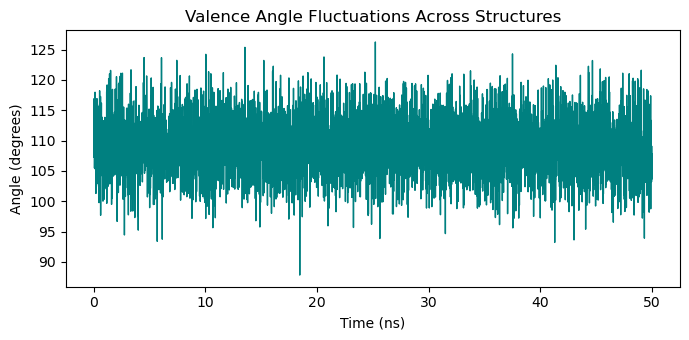

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(time_ns, angles_deg, color='teal', lw=1.0)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Valence Angle Fluctuations Across Structures')
plt.tight_layout()
plt.show()


## Computing multiple angle triplets concurrently

Multiple atom triplets can be passed simultaneously as a list of 3-tuples:


In [7]:
triplets = [[0, 1, 2], [1, 2, 3], [2, 3, 4]]
angles_multi = msm.structure.get_angles(molsys, triplets=triplets)
print('Multiple angles (degrees):', puw.convert(angles_multi, to_unit='degrees'))


Multiple angles (degrees): [[36.93684771675683 120.03546704196674 42.49416671770135]] degree


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query elements, atom indices, and attributes with {func}`molsysmt.basic.get`.
- {ref}`Get distances <Tutorial_Get_distances>`: Measure continuous distances between atoms with {func}`molsysmt.structure.get_distances`.
- {ref}`Get dihedral angles <Tutorial_Get_dihedral_angles>`: Measure dihedral and torsional angles with {func}`molsysmt.structure.get_dihedral_angles`.
:::
